# A/B Test Design and Analysis of Results

***Note: This is an educational project completed as part of a professional retraining course.*** 

This project simulates the workflow of a Product Analyst at a company developing an entertainment app with an "infinite" content feed (similar to short-video platforms). The app operates on two monetization models:
1. **Monthly paid subscription**, which allows users to browse the feed ad-free.
2. **Ad display** for users who have not subscribed yet.

The Recommendation Systems team has developed a new recommendation algorithm that they believe delivers more engaging content tailored to each user. The goal of this analysis is to determine the parameters for an A/B test to validate this hypothesis and analyze the results.
________________________________

**Table of Contents**

1. Data Description
- 1.1. Data Dictionary

2. Project Objectives

3. Exploratory Data Analysis (EDA) on Historical Data
- 3.1. Data Loading
- 3.2. Data Exploration
- 3.3. Registration Trend Analysis
- 3.4. Page Views Analysis

4. Test Preparation
- 4.1. Minimum Sample Size Calculation
- 4.2. A/B Test Duration Calculation

5. A/B Test Monitoring
- 5.1. User Sample Split Verification
- 5.2. Sample Independence & User Overlap Check
- 5.3. User Distribution Across Device Types and Regions
- 5.4. Preliminary Monitoring Findings

6. A/B Test Results Analysis
- 6.1. Loading Test Data and Target Metric Calculation
- 6.2. Hypothesis Formulation
- 6.3. Primary Metric Comparison
- 6.4. Statistical Significance of Primary Metric Change

7. Final A/B Test Conclusions & Recommendations
__________________________

## Data Description

The analysis utilizes three datasets:

- `sessions_project_history.csv` — historical user session data for the period from 2025-08-15 to 2025-09-23. File path: `datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — session data for the first day of the A/B test (2025-10-14). File path: `datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — session data for the entire A/B test duration, from 2025-10-14 to 2025-11-02. File path: `datasets/sessions_project_test.csv`.

These tables have nearly identical structures and column contents, differing only in their observation periods.

### Data Dictionary (`sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`)

- `user_id` — unique identifier for each user
- `session_id` — unique identifier for each app session
- `session_date` — session date
- `session_start_ts` — session start timestamp (date and time)
- `install_date` — app installation date
- `session_number` — sequential session number for a specific user
- `registration_flag` — flag indicating whether the user is registered
- `page_counter` — number of pages viewed during the session
- `region` — user location/region
- `device` — user device type
- `test_group` — assigned experiment group (absent in the historical dataset)

## Project Objectives

The primary objectives of this project are:
1. Calculate the core experiment parameters (sample size, minimum detectable effect, duration).
2. Evaluate the test implementation integrity and check for sample ratio mismatch or data anomalies.
3. Analyze the experiment results and make a data-driven business recommendation.

## Exploratory Data Analysis (EDA) on Historical Data

### Data Loading

At the initial stage, historical user session data was loaded and inspected:

- Imported necessary libraries (`pandas`, `matplotlib`, `statsmodels`).
- Loaded the historical session data from `datasets/sessions_project_history.csv` into the `sessions_history` DataFrame.
- Displayed the first five rows of the DataFrame to inspect the initial structure.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from math import ceil
try:
    from statsmodels.stats.power import NormalIndPower
    from statsmodels.stats.proportion import proportion_effectsize
    from statsmodels.stats.proportion import proportions_ztest
except ModuleNotFoundError:
    %pip install statsmodels

In [2]:
# Load historical session dataset
try:
    sessions_history = pd.read_csv('datasets/sessions_project_history.csv')
except FileNotFoundError:
    sessions_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


### Data Exploration

To understand the dataset structure and session recording logic:

- Calculated the total number of unique sessions (`session_id`) for each unique user (`user_id`).
- Displayed all records from `sessions_history` for a user with the highest number of sessions.
- Examined the user's session history to better understand how each feature/column is populated.

In [3]:
target_id = sessions_history['user_id'].value_counts().index[0]
sessions_history[sessions_history['user_id'] == target_id]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


### Registration Trend Analysis

One of the key product metrics is the number of registered users. Using historical data, daily registration dynamics were analyzed:

- Aggregated historical data to calculate the total number of unique users and registered users for each observation day. For simplicity, it was assumed that each user has at most one session per day and their registration status remains unchanged during a single day.
- Plotted daily line charts showing total active users and registered active users on a single chart to observe trends over time.
- Created a separate line chart showing the daily share (proportion) of registered users relative to all active users.

In [4]:
total_users = sessions_history.groupby('session_date')['user_id'].nunique()
registered_users = sessions_history[sessions_history['registration_flag']== 1].groupby('session_date')['user_id'].nunique()
registered_share = registered_users/total_users

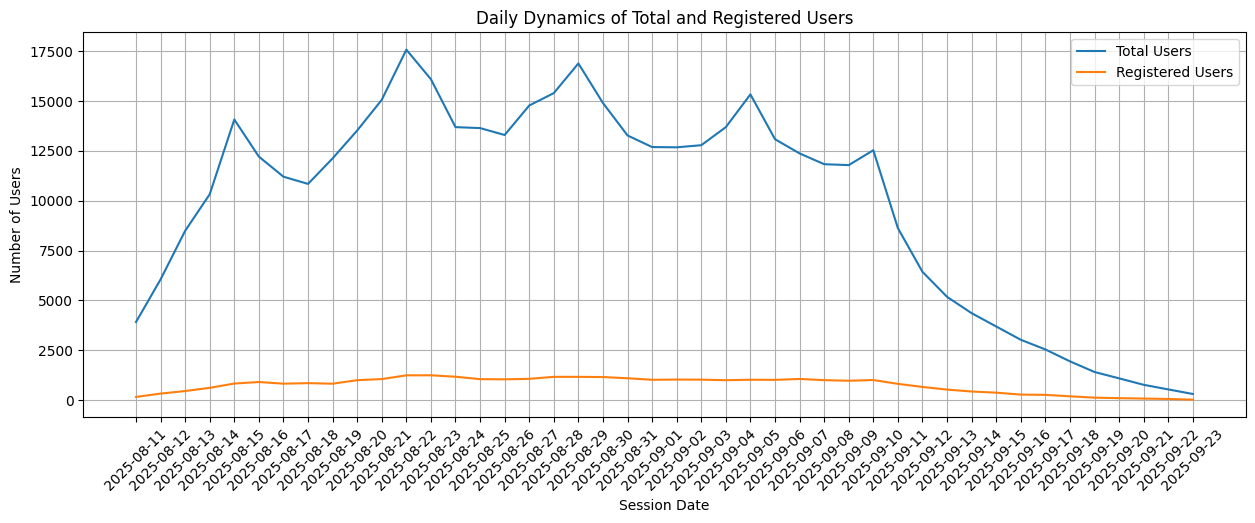

In [5]:
plt.figure(figsize=(15, 5))
plt.plot(total_users, label='Total Users')
plt.plot(registered_users, label='Registered Users')

plt.title('Daily Dynamics of Total and Registered Users')
plt.legend()
plt.xlabel('Session Date')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)   
plt.grid(True)
plt.show()

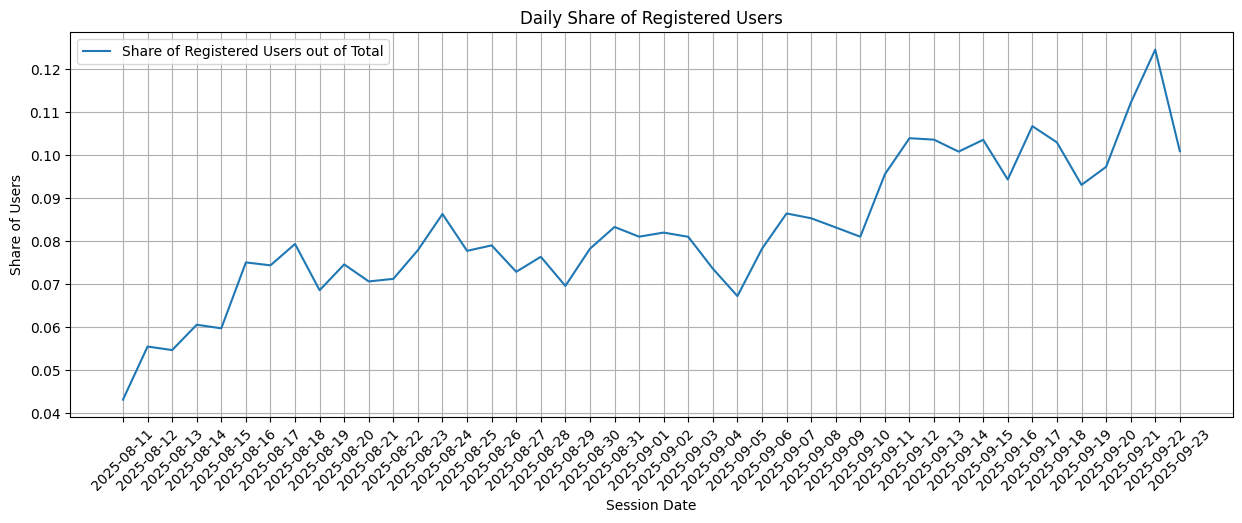

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(registered_share, label='Share of Registered Users out of Total')

plt.title('Daily Share of Registered Users')
plt.xlabel('Session Date')
plt.ylabel('Share of Users')
plt.xticks(rotation=45)   
plt.legend()
plt.grid(True)
plt.show()

### Page Views Analysis

Another critical product metric is the number of viewed pages within the app. Higher page engagement indicates stronger user involvement, which increases the likelihood of registration and subscription conversion.

- The distribution of page views during initial user sessions was analyzed by calculating the frequency of first sessions for each page view count (e.g., 8,978 first sessions with 1 page view, 32,494 with 2 page views, etc.)
- A bar chart with the number of viewed pages on the X-axis and the session count on the Y-axis was plotted. 

In [7]:
first_counter = sessions_history[sessions_history['session_number']== 1].groupby('page_counter')['session_number'].sum()
first_counter

page_counter
1     8978
2    32494
3    50939
4    32739
5     8075
6      777
7       37
Name: session_number, dtype: int64

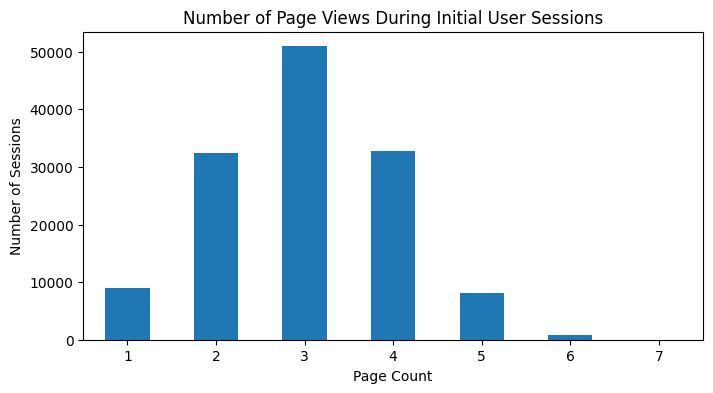

In [8]:
plt.figure(figsize = (8, 4))
first_counter.plot(kind = 'bar')

plt.title('Number of Page Views During Initial User Sessions')
plt.xlabel('Page Count')
plt.ylabel('Number of Sessions')
plt.xticks(rotation=0)   
plt.show()

**Early Engagement Indicator (Proxy Metric):** A high number of page views during the very first session serves as an early indicator that a new user finds the content engaging. Users who consume a high number of pages right after installation are significantly more likely to stay in the app, register, and eventually convert into paid subscribers. In this analysis, a **successful initial session** is defined as a user's first session in the app with at least 4 page views (`page_counter >= 4`). 

In [9]:
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype(int)

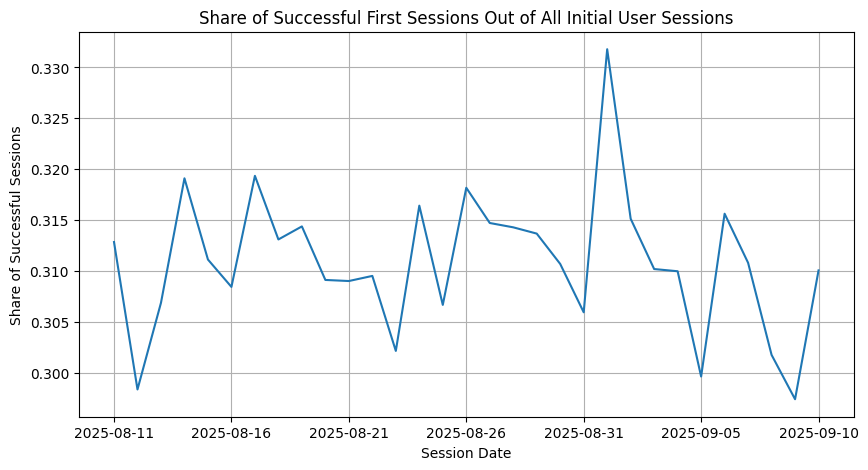

In [10]:
good_fist_share = sessions_history[sessions_history['session_number']== 1].groupby('session_date')['good_session'].mean()

plt.figure(figsize = (10, 5))
good_fist_share.plot(kind = 'line')
plt.title('Share of Successful First Sessions Out of All Initial User Sessions')
plt.xlabel('Session Date')
plt.ylabel('Share of Successful Sessions')
plt.grid()
plt.show()

## Test Preparation

Planning the A/B test involves several critical steps:
- Selecting the primary target metric.
- Calculating the required sample size.
- Determining the required test duration based on current user traffic levels.

### Minimum Sample Size Calculation

To determine the sample size needed to detect a statistically significant difference, the statistical parameters were configured as follows:
- **Significance level ($\alpha$):** 0.05
- **Type II error probability ($\beta$):** 0.20
- **Statistical power ($1 - \beta$):** 0.80
- **Minimum Detectable Effect (MDE):** 3% (expressed as a relative change / decimal fraction in calculations)

The sample size was computed using the `solve_power()` method from the `NormalIndPower` class in the `statsmodels.stats.power` module.

In [11]:
# Set parameters:
alpha = 0.05  # Significance level
beta = 0.2  # Type II error probability (1 - power)
power = 0.8  # Statistical power
p = 0.3  # Baseline conversion rate
mde = (p * 0.03)  # Minimum detectable effect (MDE)
effect_size = proportion_effectsize(p, p + mde)

# Initialize NormalIndPower class
power_analysis = NormalIndPower()

# Calculate sample size
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1  # Equal sample size distribution (1:1 split)
)

print(f"Required sample size per group: {int(sample_size)}")

Required sample size per group: 41040


### A/B Test Duration Calculation

Using the required sample size per group and the historical average daily user traffic, the experiment duration was estimated:

- Calculated the average daily number of unique active users in the app.
- Determined the test duration by dividing the total required sample size across all variant groups by the daily user traffic volume, rounding up to the nearest whole day.

In [12]:
# Average daily active users based on historical data
avg_daily_users = (sessions_history.groupby('session_date')['user_id'].nunique()).mean()

# Calculate test duration in days as total required sample size divided by average daily users
test_duration = ceil(sample_size * 2 / avg_daily_users)

print(f"Calculated A/B test duration with current traffic levels at {round(avg_daily_users, 0)} daily users is {test_duration} days.")

Calculated A/B test duration with current traffic levels at 9907.0 daily users is 9 days.


## A/B Test Monitoring

### User Sample Split Verification

After launching the A/B test, preliminary data for the initial observation period was collected. At this stage, it was essential to verify that the traffic splitting mechanism functioned correctly and that experimental groups were balanced.

- Loaded the initial test dataset from `datasets/sessions_project_test_part.csv` into the `sessions_test_part` DataFrame.
- Calculated the number of unique users assigned to each experimental group (`A` and `B`) for the first observation day.
- Computed the relative percentage difference between group sizes using the formula:
$$P = 100 \cdot \frac{\vert{}A - B\vert{}}{A}$$
- Visualized group size comparisons to inspect potential sample imbalances.

In [13]:
#Load early test data
try:
    sessions_test_part = pd.read_csv('datasets/sessions_project_test_part.csv')
except FileNotFoundError:
    sessions_test_part = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test_part.csv')

In [14]:
#Calculate unique user counts per group and percentage difference
test_summary = sessions_test_part.groupby(['session_date', 'test_group'])['user_id'].nunique().unstack()
test_summary['A_B_percent'] = round(100 * (abs(test_summary['A'] - test_summary['B']) / test_summary['A']), 2)

print(f"Number of users in Control Group (A): {test_summary['A'].iloc[0]}")
print(f"Number of users in Treatment Group (B): {test_summary['B'].iloc[0]}")
print(f"Percentage difference in user count between Groups A and B: {test_summary['A_B_percent'].iloc[0]}%")

Number of users in Control Group (A): 1477
Number of users in Treatment Group (B): 1466
Percentage difference in user count between Groups A and B: 0.74%


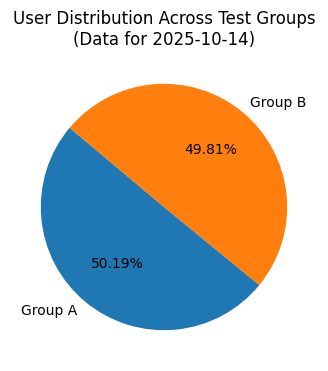

In [15]:
sizes = [test_summary['A'].iloc[0], test_summary['B'].iloc[0]]
labels = ['Group A', 'Group B']

plt.figure(figsize=(4, 4))
plt.pie(
    sizes, 
    labels=labels, 
    autopct='%1.2f%%',
    startangle=140     
)

plt.title(f"User Distribution Across Test Groups\n(Data for {test_summary.index[0]})")
plt.show()

### Sample Independence & User Overlap Check

In addition to verifying group size equality, it is essential to ensure that experimental groups are strictly independent. A user overlap check was performed to confirm that no user was inadvertently assigned to both Control (A) and Treatment (B) groups simultaneously.

In [16]:
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']
intersection = list(set(group_A) & set(group_B))

if not intersection:
    print('No user overlap found between groups.')
else:
    print("Users present in both groups:", intersection)

No user overlap found between groups.


### User Distribution Across Device Types and Regions

To ensure proper randomization without selection bias, the balance of categorical features across experimental groups was evaluated:

- Computed the proportion of each device type for users in Control Group A and Treatment Group B and built visualization charts comparing device distributions between Group A and Group B.
- Calculated the proportion of users from each region for Control Group A and Treatment Group B and created visualizations comparing regional shares between Group A and Group B.

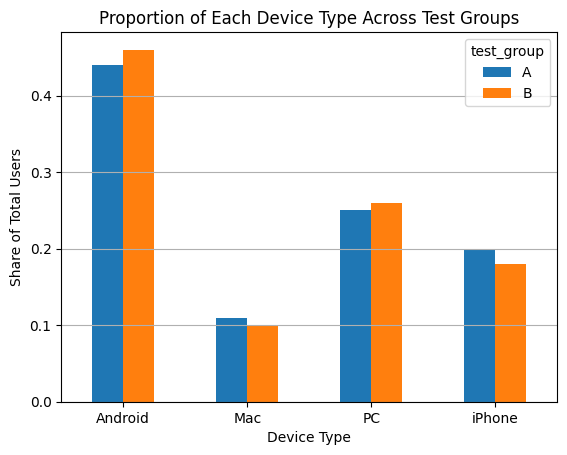

In [17]:
# Aggregate unique users by test group and device type
devices = sessions_test_part.groupby(['test_group', 'device'])['user_id'].nunique().unstack().T

# Calculate the proportion of each device type relative to group totals
devices_share = round(devices/devices.sum(), 2)

# Plot device distribution across test groups
devices_share.plot(kind='bar', title='Proportion of Each Device Type Across Test Groups')
plt.xlabel('Device Type')
plt.ylabel('Share of Total Users')
plt.xticks(rotation=0) 
plt.grid(axis='y')
plt.show()

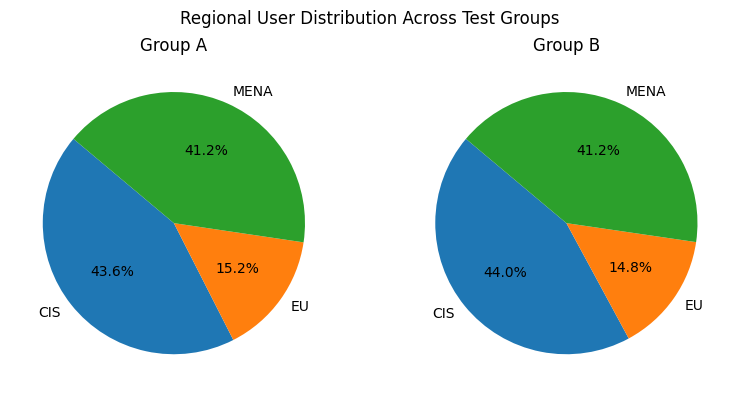

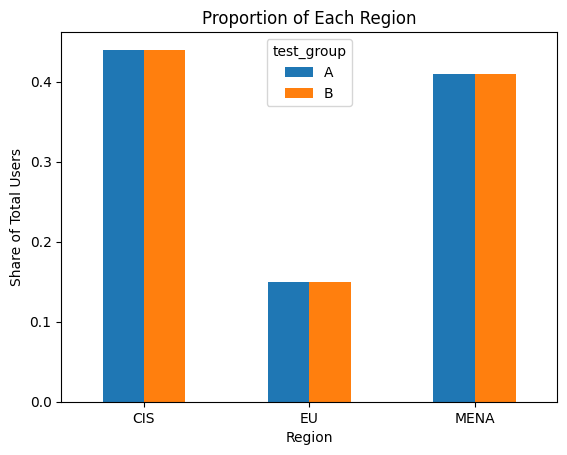

In [18]:
# Aggregate unique users by test group and region
regions = sessions_test_part.groupby(['test_group', 'region'])['user_id'].nunique().unstack().T

# Create pie charts for visual comparison between groups
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# Plot region breakdown for Group A
ax1.pie(regions['A'], labels=regions.index, autopct='%1.1f%%', startangle=140)
ax1.set_title('Group A')

# Plot region breakdown for Group B
ax2.pie(regions['B'], labels=regions.index, autopct='%1.1f%%', startangle=140)
ax2.set_title('Group B')

fig.suptitle('Regional User Distribution Across Test Groups')
plt.tight_layout()
plt.show()

# Calculate relative proportions for each region
regions_share = round(regions / regions.sum(), 2)

# Plot bar chart comparing regional proportions
regions_share.plot(kind='bar', title='Proportion of Each Region')

plt.xlabel('Region')
plt.ylabel('Share of Total Users')
plt.xticks(rotation=0) 
plt.show()

### Preliminary Monitoring Findings and Conclusion

Based on the initial data analysis of the A/B test setup, the following observations were made regarding sample balance and implementation integrity:

- **Group Size Balance:** The user allocation between Control (Group A) and Treatment (Group B) was evaluated for the first day of observation. The percentage difference between the group sizes remained well within acceptable limits, indicating that the traffic-splitting algorithm distributes users evenly.
- **Sample Independence:** No user overlap was detected between the experimental variants. The samples are strictly independent, ruling out cross-contamination risk.
- **Categorical Feature Distribution:** 
  - **Device Types:** The proportion of users across device categories (e.g., mobile vs. desktop) remains identical between Group A and Group B.
  - **Geographic Regions:** The regional breakdown shows consistent user proportions across both groups, confirming balanced geographic representation.

**Conclusion:** 
The A/B test framework is functioning correctly without technical anomalies or sample ratio mismatches (SRM). The user splitting, sample independence, and feature balance criteria are fully satisfied, allowing the experiment to proceed as planned.

## A/B Test Results Analysis

The A/B test has concluded, and complete session data for the entire experiment duration is now available. This phase focuses on verifying experiment validity and interpreting the final statistical outcome.

### Loading Test Data and Target Metric Calculation

- Loaded the complete experimental dataset from `datasets/sessions_project_test.csv` into the `sessions_test` DataFrame.
- Created the target binary indicator `good_session`: assigned `1` if the session contained 4 or more page views (`page_counter >= 4`), and `0` otherwise.

In [19]:
# Load full test session data
try:
    sessions_test = pd.read_csv('datasets/sessions_project_test.csv')
except FileNotFoundError:
    sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')

In [20]:
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B


In [21]:
# Display summary information about the DataFrame structure and data types
print(sessions_test.info())

# Print total observation period duration
print('Data provided for', sessions_test['session_date'].nunique(), 'days.')

# Count unique users in control (A) and treatment (B) groups
group_a = sessions_test[sessions_test['test_group']=='A']['user_id'].nunique()
group_b = sessions_test[sessions_test['test_group']=='B']['user_id'].nunique()
print(f'group_a: {group_a} unique users, group_b: {group_b} unique users.')

<class 'pandas.DataFrame'>
RangeIndex: 100005 entries, 0 to 100004
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   user_id            100005 non-null  str  
 1   session_id         100005 non-null  str  
 2   session_date       100005 non-null  str  
 3   session_start_ts   100005 non-null  str  
 4   install_date       100005 non-null  str  
 5   session_number     100005 non-null  int64
 6   registration_flag  100005 non-null  int64
 7   page_counter       100005 non-null  int64
 8   region             100005 non-null  str  
 9   device             100005 non-null  str  
 10  test_group         100005 non-null  str  
dtypes: int64(3), str(8)
memory usage: 8.4 MB
None
Data provided for 20 days.
group_a: 15163 unique users, group_b: 15416 unique users.


In [22]:
# Create target metric: binary indicator for successful initial session
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)

### Hypothesis Formulation

Before conducting statistical testing, explicit experimental hypotheses and metric frameworks were defined. The goal of the new recommendation algorithm is to deliver more engaging content tailored to each user.

- **Primary (Target) Metric:** The proportion of successful initial sessions. A positive first impression is critical for driving registration and downstream subscription conversion.
- **Proxy Metric:** Average pages viewed per session. An increase in page depth serves as an early indicator of algorithm engagement prior to evaluating conversion rates.
- **Guardrail Metric:** Average session frequency per user. A decrease in repeat sessions would signal potential user churn and long-term revenue loss, even if initial session performance appears high.

#### Experimental Hypotheses:
- **Null Hypothesis ($H_0$):** There is no difference in the proportion of successful initial sessions between Group A and Group B ($p_A = p_B$).
- **Alternative Hypothesis ($H_1$):** The proportion of successful initial sessions in Group B is greater than in Group A ($p_A < p_B$).

### Primary Metric Comparison

Evaluating the baseline target metric across both experimental groups for initial user sessions (`session_number == 1`):

In [23]:
# Calculate the share of successful first sessions for Groups A and B
good_first_session_A_share = sessions_test[(sessions_test['test_group'] == 'A') & (sessions_test['session_number'] == 1)]['good_session'].mean()
good_first_session_B_share = sessions_test[(sessions_test['test_group'] == 'B') & (sessions_test['session_number'] == 1)]['good_session'].mean()

print('Share of successful first sessions in Group A:', round(good_first_session_A_share, 3))
print('Share of successful first sessions in Group B:', round(good_first_session_B_share, 3))
print('Absolute difference:', round(good_first_session_A_share - good_first_session_B_share, 3))

Share of successful first sessions in Group A: 0.316
Share of successful first sessions in Group B: 0.315
Absolute difference: 0.001


### Statistical Significance of Primary Metric Change

While the observed baseline proportions of successful first sessions were close, business decisions cannot be made on raw point estimates alone. Hypothesis testing was conducted to determine whether the difference in target metric performance between the two groups is statistically significant.

- Performed a two-sample Z-test for proportions to evaluate the statistical significance of the metric change.
- Compared the calculated $p$-value against the predefined significance threshold ($\alpha = 0.05$).

In [24]:
alpha = 0.05
n_a = sessions_test[(sessions_test['test_group'] == 'A')&(sessions_test['session_number']==1)]['good_session'].count()
n_b = sessions_test[(sessions_test['test_group'] == 'B')&(sessions_test['session_number']==1)]['good_session'].count()
m_a = sessions_test[(sessions_test['test_group'] == 'A')&(sessions_test['session_number']==1)]['good_session'].sum()
m_b = sessions_test[(sessions_test['test_group'] == 'B')&(sessions_test['session_number']==1)]['good_session'].sum()

stat_ztest, p_value_ztest = proportions_ztest(
    nobs = [n_a, n_b], 
    count = [m_a, m_b],
    alternative = 'smaller'
)

if p_value_ztest > alpha:
    print(f'{round(p_value_ztest, 2)} > {alpha}.', 
          'Failed to reject the null hypothesis. No statistically significant difference in the share of successful first sessions was detected\
          between groups.')
else:
    print(f'{round(p_value_ztest, 2)} < {alpha}.', 
          'Reject the null hypothesis. The new algorithm resulted in a statistically significant increase in the share of successful first sessions.')

0.58 > 0.05. Failed to reject the null hypothesis. No statistically significant difference in the share of successful first sessions was detected          between groups.


## Final A/B Test Conclusions & Recommendations

Based on the statistical analysis of the completed A/B experiment, the final results and recommendations for the product and development teams are summarized below:

- **Experiment Parameters & Scope:**
  - **Calculated Requirements:** The minimum required sample size was set to 41,040 users per group with an estimated duration of 9 days.
  - **Actual Execution:** The experiment ran for 20 days, accumulating a total of 100,005 session records across approximately 15,000 unique users per group.
- **Metric Impact & Statistical Significance:**
  - The calculated $p$-value for the two-sample Z-test was **0.58**, which exceeds the chosen significance threshold ($\alpha = 0.05$).
  - Consequently, we fail to reject the null hypothesis. There is no statistically significant evidence to suggest that the new recommendation algorithm improved the proportion of successful initial sessions.
- **Product Decision:**
  - **Recommendation:** **Do not roll out** the new recommendation algorithm to production. The proposed changes showed no measurable positive impact on initial user engagement and do not justify the implementation and maintenance costs.